In [1]:
# Chest X-ray Pneumonia Classifier (Beginner Project)

This is my first AI project.
Goal: Teach a computer to tell **Normal** vs **Pneumonia** from chest X-rays.


SyntaxError: invalid syntax (ipython-input-1751863847.py, line 3)

In [2]:
# Install tools we need (only once per session)
!pip install torch torchvision torchaudio
!pip install scikit-learn pandas matplotlib seaborn


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt


In [4]:
print("Hello, this is my first AI notebook!")


Hello, this is my first AI notebook!


In [5]:
from google.colab import files
files.upload()   # choose kaggle.json when prompted


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammedomarjee","key":"4db6b1d7c9bcd490a813a8f4e4c03182"}'}

In [6]:
import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle key installed ✅")


Kaggle key installed ✅


In [7]:
!pip -q install kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content
!unzip -q /content/chest-xray-pneumonia.zip -d /content
!ls /content/chest_xray


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 97% 2.24G/2.29G [00:20<00:01, 39.3MB/s]
100% 2.29G/2.29G [00:20<00:00, 119MB/s] 
chest_xray  __MACOSX  test  train  val


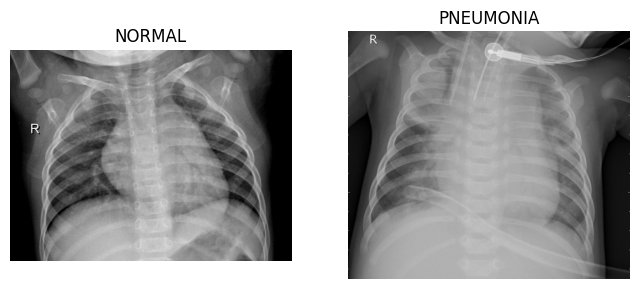

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Pick a folder of normal images
normal_dir = "/content/chest_xray/train/NORMAL"
pneumonia_dir = "/content/chest_xray/train/PNEUMONIA"

# Get one example from each
normal_img = os.path.join(normal_dir, os.listdir(normal_dir)[0])
pneumonia_img = os.path.join(pneumonia_dir, os.listdir(pneumonia_dir)[0])

# Show them side by side
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(mpimg.imread(normal_img), cmap='gray')
ax[0].set_title("NORMAL")
ax[0].axis("off")

ax[1].imshow(mpimg.imread(pneumonia_img), cmap='gray')
ax[1].set_title("PNEUMONIA")
ax[1].axis("off")

plt.show()


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224   # small & fast
BATCH    = 16    # how many images at a time

# Basic resizing + convert to tensor (numbers the model understands)
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),   # tiny bit of variety
    transforms.ToTensor()
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dir = "/content/chest_xray/train"
val_dir   = "/content/chest_xray/val"
test_dir  = "/content/chest_xray/test"

train_ds = datasets.ImageFolder(train_dir, transform=train_tf)
val_ds   = datasets.ImageFolder(val_dir,   transform=val_tf)
test_ds  = datasets.ImageFolder(test_dir,  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

class_names = train_ds.classes
class_names


['NORMAL', 'PNEUMONIA']

In [10]:
import torch
import torch.nn as nn
import torchvision.models as models

# Use the GPU if available (faster). If not, CPU is fine.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Load a small, proven image model that already knows about pictures
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Change the last layer so it outputs 2 classes (NORMAL, PNEUMONIA)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move the model to the device (GPU/CPU)
model = model.to(device)

# Tell the model how to measure right vs wrong (loss) and how to improve (optimizer)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

print("Model is ready ✅")


Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Model is ready ✅


In [11]:
def run_epoch(dataloader, training=False):
    if training:
        model.train()
    else:
        model.eval()

    total, correct, total_loss = 0, 0, 0.0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(x)
            loss = criterion(logits, y)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

# Run a tiny training loop
EPOCHS = 2  # keep it short for a first try
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(train_dl, training=True)
    va_loss, va_acc = run_epoch(val_dl, training=False)
    print(f"Epoch {epoch+1}: train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")


Epoch 1: train loss 0.103 acc 0.959 | val loss 0.229 acc 0.938
Epoch 2: train loss 0.054 acc 0.980 | val loss 0.069 acc 0.938


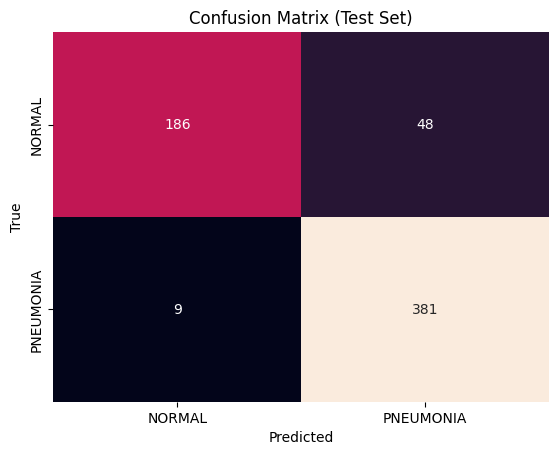

              precision    recall  f1-score   support

      NORMAL       0.95      0.79      0.87       234
   PNEUMONIA       0.89      0.98      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.89      0.90       624
weighted avg       0.91      0.91      0.91       624



In [12]:
import torch, numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the TEST set
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()  # 0=NORMAL, 1=PNEUMONIA
        all_pred.append(preds)
        all_true.append(y.numpy())

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

# Confusion matrix
cm = confusion_matrix(all_true, all_pred)

sns.heatmap(cm, annot=True, fmt="d", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

print(classification_report(all_true, all_pred, target_names=class_names))


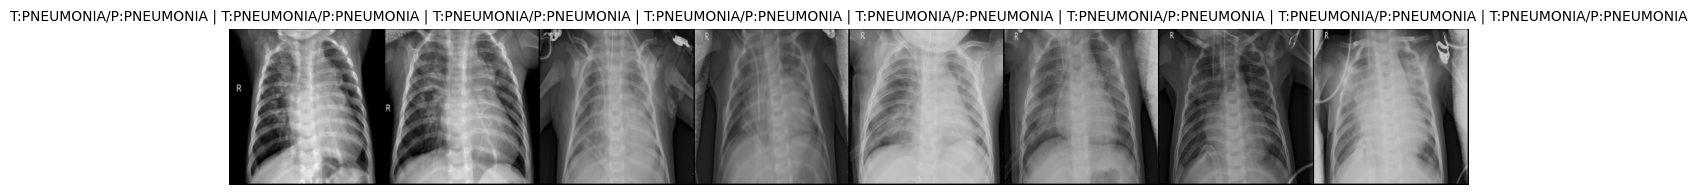

In [16]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Get one batch from the test loader
model.eval()
import random

# Pick a random batch number
rand_idx = random.randint(0, len(test_dl)-1)

for i, (x, y) in enumerate(test_dl):
    if i == rand_idx:
        x_batch, y_true = x, y
        break

x_batch = x_batch.to(device)

with torch.no_grad():
    logits = model(x_batch)
    y_pred = logits.argmax(1).cpu()

# Move images back to CPU for plotting
imgs = x_batch.cpu()

# How many images to show in a row (change 8 → 6 or 10 if you want)
N = min(8, imgs.size(0))

# Build a grid of N images
grid = make_grid(imgs[:N], nrow=N, padding=2)
plt.figure(figsize=(2*N, 3))
plt.imshow(grid.permute(1, 2, 0))   # convert tensor to HxWxC for matplotlib
plt.axis("off")

# Build a title with True/Pred labels
title_parts = []
for t, p in zip(y_true[:N].tolist(), y_pred[:N].tolist()):
    title_parts.append(f"T:{class_names[t]}/P:{class_names[p]}")
plt.title(" | ".join(title_parts), fontsize=10)
plt.show()


Saved: cxr_predictions_grid.png


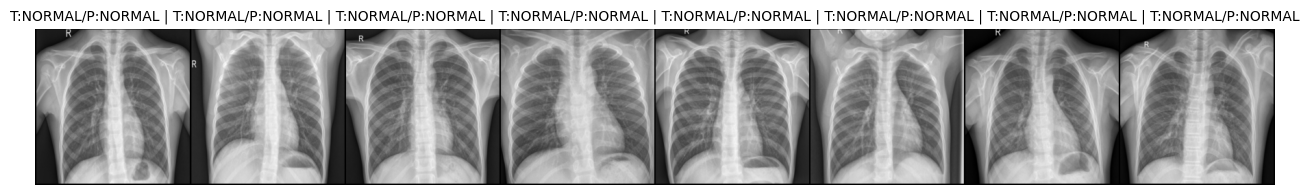

In [14]:
plt.figure(figsize=(2*N, 3))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title(" | ".join(title_parts), fontsize=10)
plt.savefig("cxr_predictions_grid.png", dpi=200, bbox_inches="tight")
print("Saved: cxr_predictions_grid.png")


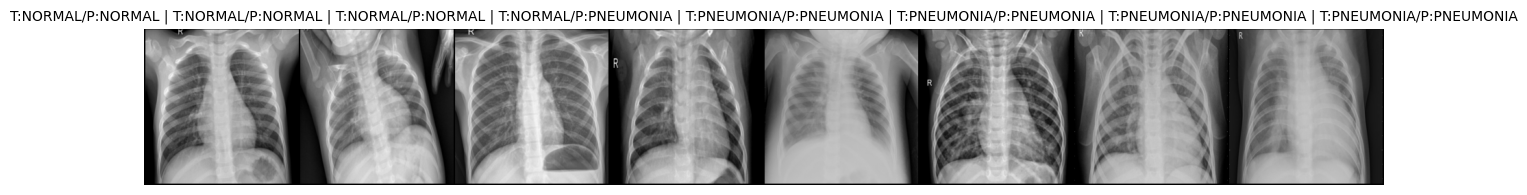

In [17]:
import os, random
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

normal_dir = "/content/chest_xray/test/NORMAL"
pneumo_dir = "/content/chest_xray/test/PNEUMONIA"

N_PER_CLASS = 4  # change to 5 for 10 images total

# pick N random files from each folder
norm_files  = random.sample(os.listdir(normal_dir), N_PER_CLASS)
pneum_files = random.sample(os.listdir(pneumo_dir), N_PER_CLASS)

# use the SAME val_tf you defined earlier
imgs, labels = [], []
for f in norm_files:
    im = Image.open(os.path.join(normal_dir, f)).convert("RGB")
    imgs.append(val_tf(im))     # transform → tensor
    labels.append(0)            # NORMAL = 0

for f in pneum_files:
    im = Image.open(os.path.join(pneumo_dir, f)).convert("RGB")
    imgs.append(val_tf(im))
    labels.append(1)            # PNEUMONIA = 1

x_batch = torch.stack(imgs).to(device)
y_true  = torch.tensor(labels)

# predict
model.eval()
with torch.no_grad():
    logits = model(x_batch)
    y_pred = logits.argmax(1).cpu()

# grid
N = len(imgs)
grid = make_grid(x_batch.cpu(), nrow=N, padding=2)
plt.figure(figsize=(2*N, 3))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
title = " | ".join([f"T:{class_names[t]}/P:{class_names[p]}" for t,p in zip(y_true.tolist(), y_pred.tolist())])
plt.title(title, fontsize=10)
plt.show()


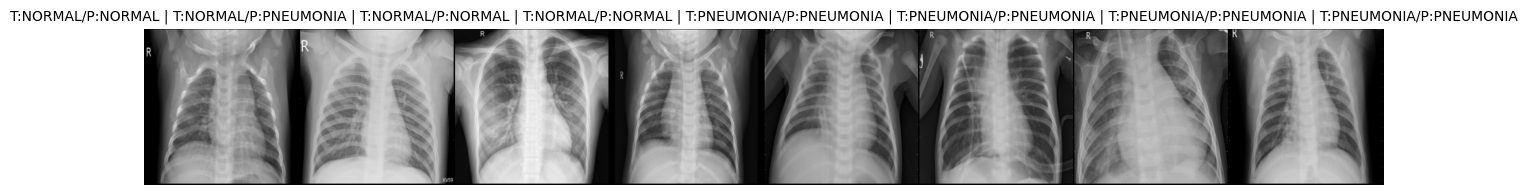

In [18]:
import os, random
from PIL import Image
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

normal_dir = "/content/chest_xray/test/NORMAL"
pneumo_dir = "/content/chest_xray/test/PNEUMONIA"

N_PER_CLASS = 4  # change to 5 for 10 images total

# pick N random files from each folder
norm_files  = random.sample(os.listdir(normal_dir), N_PER_CLASS)
pneum_files = random.sample(os.listdir(pneumo_dir), N_PER_CLASS)

# use the SAME val_tf you defined earlier
imgs, labels = [], []
for f in norm_files:
    im = Image.open(os.path.join(normal_dir, f)).convert("RGB")
    imgs.append(val_tf(im))     # transform → tensor
    labels.append(0)            # NORMAL = 0

for f in pneum_files:
    im = Image.open(os.path.join(pneumo_dir, f)).convert("RGB")
    imgs.append(val_tf(im))
    labels.append(1)            # PNEUMONIA = 1

x_batch = torch.stack(imgs).to(device)
y_true  = torch.tensor(labels)

# predict
model.eval()
with torch.no_grad():
    logits = model(x_batch)
    y_pred = logits.argmax(1).cpu()

# grid
N = len(imgs)
grid = make_grid(x_batch.cpu(), nrow=N, padding=2)
plt.figure(figsize=(2*N, 3))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
title = " | ".join([f"T:{class_names[t]}/P:{class_names[p]}" for t,p in zip(y_true.tolist(), y_pred.tolist())])
plt.title(title, fontsize=10)
plt.show()


Saved as cxr_predictions_grid.png ✅


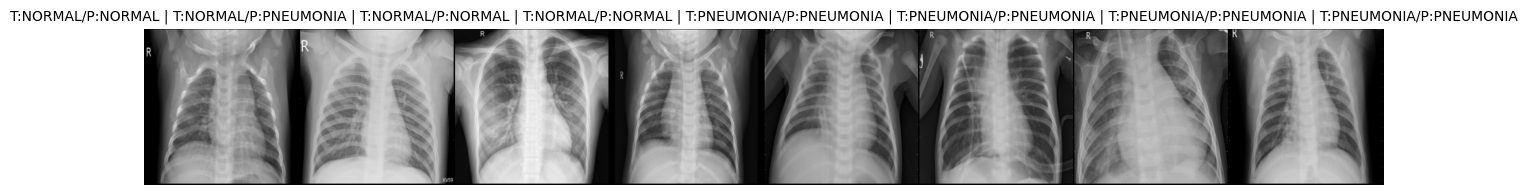

In [20]:
# Save the prediction grid as a PNG file
plt.figure(figsize=(2*N, 3))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")
plt.title(title, fontsize=10)

plt.savefig("cxr_predictions_grid.png", dpi=200, bbox_inches="tight")
print("Saved as cxr_predictions_grid.png ✅")
